-----TEMEL-TEKNİK-GÜRÜLTÜ AJANLARI ORANI SİMÜLASYONU--------


Python mesa kütüphanesi kullanarak bir finansal piyasa simülasyonu yapmak istiyorum. Piyasada temel, teknik ve gürültü ajanları olacak. Piyasada toplam ajan sayısı 1200'dür. Temel ajanların kullandığı strateji 4 adettir ve her bir stratejiyi kullanan ajan sayısı 100'dür. Teknik ajanların kullandığı strateji 4 adettir ve her bir stratejiyi kullanan ajan sayısı 100'dür.  Gürültü ajanların kullandığı strateji 4 adettir ve her bir stratejiyi kullanan ajan sayısı 100'dür. 4 adet simülasyon yapacağız. Birinci simülasyonda sadece temel ajanların olduğu simülasyon olacak. İkinci simülasyonda sadece teknik ajanların olduğu simülasyon olacak. Üçüncü simülasyonda sadece gürültü ajanların olduğu simülasyon olacak. Dördüncü simülasyonda temel, teknik ve gürültü ajanların olduğu simülasyon olacak. Dördüncü simülasyonda temel, teknik ve gürültü ajanların oranlarını farklı denemelerle uygun oranı bulmaya çalışacağız.


| Simülasyon | Ajan Türü | Strateji Sayısı | Ajan Başına Strateji Sayısı | Toplam Ajan |
| ---------- | --------- | --------------- | --------------------------- | ----------- |
| 1          | Temel     | 4               | 100                         | 400         |
| 2          | Teknik    | 4               | 100                         | 400         |
| 3          | Gürültü   | 4               | 100                         | 400         |
| 4          | Karışık   | 4+4+4           | Denenecek                   | 1200        |



#Temel Ajan Stratejileri (Örnek)

DCF bazlı değerleme

Göreli fiyatlamaya dayalı değerleme

Makroekonomik haber temelli pozisyon alma

Sektörel karşılaştırmalı değerleme


#Teknik Ajan Stratejileri (Örnek)

Momentum

Contrarian

Fibonacci geri dönüşleri

RSI/MA sinyalleri

#Gürültü Ajan Stratejileri (Örnek)

Rastgele al-sat

Geçmiş adıma göre yön tahmini

Çok kısa vadeli hareketlere tepki

Başka bir ajanı takip etme (herding)

##🏗️ MESA Uygulama Yapısı (Genel Sınıf Mimarisi)

    # agents.py
    class BaseAgent(Agent):
        def __init__(self, unique_id, model, strategy):
            super().__init__(unique_id, model)
            self.strategy = strategy

        def step(self):
            # Stratejiye göre karar al
            pass

    class FundamentalAgent(BaseAgent): ...
    class TechnicalAgent(BaseAgent): ...
    class NoiseAgent(BaseAgent): ...

    # model.py
    class MarketModel(Model):
        def __init__(self, agent_config):
            self.schedule = SimultaneousActivation(self)
            self.datacollector = DataCollector(...)
            self.price = INITIAL_PRICE
            self.create_agents(agent_config)

        def create_agents(self, agent_config):
            uid = 0
            for agent_type, strategy_counts in agent_config.items():
                for strategy, count in strategy_counts.items():
                    for _ in range(count):
                        if agent_type == 'fundamental':
                            agent = FundamentalAgent(uid, self, strategy)
                        elif agent_type == 'technical':
                            agent = TechnicalAgent(uid, self, strategy)
                        elif agent_type == 'noise':
                            agent = NoiseAgent(uid, self, strategy)
                        self.schedule.add(agent)
                        uid += 1

        def step(self):
            self.schedule.step()
            self.datacollector.collect(self)


##⚙️ Simülasyon Senaryoları


    # run_simulations.py

    def get_agent_config(simulation_id):
        if simulation_id == 1:
            return {'fundamental': {0:100, 1:100, 2:100, 3:100}}
        elif simulation_id == 2:
            return {'technical': {0:100, 1:100, 2:100, 3:100}}
        elif simulation_id == 3:
            return {'noise': {0:100, 1:100, 2:100, 3:100}}
        elif simulation_id == 4:
            return {
                'fundamental': {0:100, 1:100, 2:100, 3:100},
                'technical': {0:100, 1:100, 2:100, 3:100},
                'noise': {0:100, 1:100, 2:100, 3:100}
            }

    for sim_id in [1, 2, 3, 4]:
        config = get_agent_config(sim_id)
        model = MarketModel(config)
        for i in range(NUM_STEPS):
            model.step()
        # Sonuçları kaydet

#📊 Veri Toplama Önerisi
Fiyat serisi

Ajanların kar/zarar oranı

Strateji başına ortalama başarı

Volatilite, otokorelasyon gibi piyasa göstergeleri

Ajan tipleri arası etkileşim (4. senaryo için)

#📚 Akademik Temellendirme
İlgili Literatür
LeBaron (2001): Agent-based computational finance.

Hommes (2006): Heterogeneous agent models in economics and finance.

Chiarella et al. (2007): Technical analysis and noise traders.

Lux (1998): Herd behavior, bubbles, and crashes.

Eleştirel Yorum
Gürültü ajanların sistemik etkisi bazen teknik ajanlardan fazla olabilir.

Temel ajanlar uzun vadeli kazanç sağlarken kısa vadede zayıf performans gösterebilir.

Karışık simülasyonlarda dominant stratejinin oluşmaması için çeşitliliğin korunması gerekir. Bu durumda evrimsel güncellemeler eklenebilir (örn. strateji değiştirme, öğrenme).

#🔁 Dördüncü Simülasyonda Oran Arama Stratejisi
Örneğin:

Fund:Tech:Noise = (4:4:4) → (6:3:3) → (3:6:3) gibi varyasyonlarla 10'dan fazla senaryo test edilebilir.

Her birinde toplam piyasa performansı, ajan refahı ve volatilite analiz edilir.

Grid search / Bayes optimizasyonu ile optimum oran tespit edilebilir.

#🔄 İleri Adımlar
Strateji başarılarına göre evrimsel güncellemeler (GA, seçim, mutasyon)

Bounded rationality & prospect theory ile davranışsal ajanlar

UI ile görselleştirme (Canvas + Chart)

Çoklu varlık modeli (ABC piyasaları) ve korelasyon entegrasyonu

İstersen tüm bu yapıyı tek tek Python sınıfları halinde adım adım inşa edebiliriz. Her ajan sınıfını ayrı ayrı tanımlayıp ardından model ve koşu dosyasını yapılandırırız.

Latex formatında teorik modeli ve stratejileri ister misiniz?

###📘 1. Teorik Model (LaTeX Formatında)

# Ajan Tabanlı Finansal Piyasa Simülasyonu: Temel, Teknik ve Gürültü Ajanlar

## Giriş
Bu çalışmada, ajan tabanlı modelleme yaklaşımı ile finansal bir piyasa simülasyonu gerçekleştirilmiştir. Piyasada üç tip ajan tanımlanmıştır: Temel (fundamental), Teknik (technical) ve Gürültü (noise) ajanlar. Her bir ajan grubu, dört farklı yatırım stratejisine sahiptir. Simülasyonlar farklı kombinasyonlarla dört senaryo üzerinden yürütülmüştür.

## Piyasa Yapısı
Zaman ayrık olup her adımda ajanlar piyasayı analiz eder ve işlem yapar. Fiyat güncellemesi arz-talep dengesine göre belirlenir. Başlangıç fiyatı P₀ sabittir. Zaman t=1,2,...,T.

### Fiyat Güncelleme Kuralı
Toplam alım (Dₜ) ve satım (Sₜ) talepleri dikkate alınarak fiyat şu şekilde güncellenir:

Pₜ₊₁ = Pₜ (1 + α · (Dₜ - Sₜ)/N)

Burada:
- Pₜ: Zaman t'deki fiyat
- Dₜ, Sₜ: Toplam alım ve satım talepleri
- N: Toplam ajan sayısı
- α: Fiyat duyarlılık katsayısı

## Ajan Türleri ve Stratejiler
Toplam üç ana ajan tipi vardır. Her biri 4 farklı strateji uygular.

### Temel Ajanlar
Piyasanın gerçek değeri Vₜ ile fiyat Pₜ arasındaki farka göre işlem yaparlar:

**Stratejiler:**
1. **DCF**: Vₜ indirgenmiş nakit akışlarına dayalı olarak hesaplanır.
2. **Göreli Değerleme**: Benzer firmalarla kıyaslama yapılır.
3. **Haber Bazlı**: Makroekonomik haber skorlarına göre Vₜ güncellenir.
4. **Sektörel Karşılaştırma**: A sektörü diğer sektörlere göre karşılaştırılır.

**İşlem kuralı:**
Buy if Vₜ - Pₜ > θ_F, Sell if Vₜ - Pₜ < -θ_F

### Teknik Ajanlar
Fiyatın geçmiş hareketlerine göre işlem yaparlar.

**Stratejiler:**
1. **Momentum**: Pₜ > Pₜ₋ₖ ise alım
2. **Contrarian**: Pₜ < Pₜ₋ₖ ise alım
3. **Fibonacci**: Fibo geri dönüş noktalarına göre işlem
4. **RSI/MA**: RSI ve hareketli ortalama kesişimi

### Gürültü Ajanlar
Kararları tamamen rastgele veya sezgisel kurallara dayalıdır.

**Stratejiler:**
1. %50 ihtimalle alım/satım
2. Önceki adımdaki fiyat değişimine göre tepki
3. Son işlemine zıt işlem yapma (reverse)
4. Rastgele başka bir ajanı takip etme (herding)

## Simülasyon Senaryoları
1. Sadece temel ajanlar (400 ajan)
2. Sadece teknik ajanlar (400 ajan)
3. Sadece gürültü ajanlar (400 ajan)
4. Karışık yapı (her tipten 400'er ajan; oran varyasyonu denenebilir)

## Sonuçlar
Her simülasyonun sonunda fiyat serileri, volatilite, strateji başarımı ve piyasa davranışı analiz edilir.

###🛠️ 2. Python Kodlama Adımları (Genel Plan)
Sıradaki adımlarda aşağıdaki yapıyı kuracağız:

1. agent.py

BaseAgent (üst sınıf)

FundamentalAgent

TechnicalAgent

NoiseAgent

2. strategy.py

Strateji fonksiyonları (her grup için ayrı)

Örneğin: momentum_strategy(agent, model)

3. model.py

MarketModel

Fiyat güncelleme, talep/satım hesaplama

Veri toplayıcı

4. run_simulations.py

4 ayrı senaryoyu çalıştıracak yapı

Verileri CSV'ye kaydetme veya grafik üretme

İlk adım olarak BaseAgent, FundamentalAgent, TechnicalAgent, ve NoiseAgent sınıflarını yazalım


Aşağıda Python mesa kütüphanesi kullanılarak oluşturulmuş BaseAgent, FundamentalAgent, TechnicalAgent ve NoiseAgent sınıfları yer almakta. Bu sınıflar, strateji uygulamalarını dış bir strategy.py dosyasından alacak şekilde yapılandırılmıştır (bu sayede stratejileri modüler biçimde ekleyebiliriz).





In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

In [12]:

class BaseAgent(mesa.Agent):
    def __init__(self, model, agent_type, strategy_id):
        super().__init__(model)
        self.agent_type = agent_type  # 'fundamental', 'technical', 'noise'
        self.strategy_id = strategy_id  # 0, 1, 2, 3 (her tür için 4 strateji)
        self.cash = 1000.0
        self.asset = 0
        self.last_action = None  # 'buy', 'sell', 'hold'

    def step(self):
        raise NotImplementedError("This method should be implemented by subclasses.")


class FundamentalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "fundamental", strategy_id)

    def step(self):
        #from strategies import fundamental_strategies
        action = fundamental_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class TechnicalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "technical", strategy_id)

    def step(self):
        #from strategies import technical_strategies
        action = technical_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class NoiseAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "noise", strategy_id)

    def step(self):
        #from strategies import noise_strategies
        action = noise_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


🔧 Notlar

Her Agent tipi:

Kendi stratejisini strategy_id aracılığıyla uygular.

step() fonksiyonu içinde stratejiyi çağırır ve işlemi uygular.

Stratejiler dış dosyadan (strategies.py) çağrılır. Bu sayede her ajan tipi için 4 stratejiyi modüler olarak yazabileceğiz.

Ajanlar:

Varlık alım/satımı yapar.

Modelin total_demand ve total_supply değişkenlerini günceller.

Fiyat güncellemesi model içinde yapılacak.

🧭 Sonraki Adım
Bir sonraki adım olarak aşağıdakilerden birini yapabiliriz:

strategies.py dosyasını oluşturup her ajan tipi için 4’er strateji tanımlayabiliriz.
*italik metin*
model.py dosyasını yazıp fiyat güncelleme, ajan yerleşimi ve zaman adımı yönetimini kurabiliriz.


sırayla şunları yapalım:

1. strategies.py dosyasını oluşturup her ajan tipi için 4’er strateji tanımlayabiliriz.

2. model.py dosyasını yazıp fiyat güncelleme, ajan yerleşimi ve zaman adımı yönetimini kurabiliriz.

Aşağıda her temel (fundamental), teknik (technical) ve gürültü (noise) ajan tipi için 4’er adet temel strateji yer almaktadır. Stratejiler sade ve örnek amaçlı olup, ilerleyen adımlarda detaylandırılabilir (örneğin haber etkisi, teknik göstergeler, öğrenme algoritmaları vb.).

📁 strategies.py

In [14]:
import random

# === FUNDAMENTAL AGENT STRATEGIES ===
def fundamental_strategy_0(agent, model):
    """Basit Değer Stratejisi: Fiyat < Temel Değerse al."""
    if model.price < model.fundamental_value:
        return "buy"
    elif model.price > model.fundamental_value:
        return "sell"
    return "hold"

def fundamental_strategy_1(agent, model):
    """Ortalama Dönüş: Fiyat, temel değere yaklaşırken satış eğilimi göster."""
    distance = model.price - model.fundamental_value
    if distance > 5:
        return "sell"
    elif distance < -5:
        return "buy"
    return "hold"

def fundamental_strategy_2(agent, model):
    """Trend Takip (Fundamental bazlı): Temel değer artıyorsa al."""
    if model.fundamental_value > model.prev_fundamental_value:
        return "buy"
    elif model.fundamental_value < model.prev_fundamental_value:
        return "sell"
    return "hold"

def fundamental_strategy_3(agent, model):
    """Temel Değer Volatilitesine Göre Tepki."""
    change = abs(model.fundamental_value - model.prev_fundamental_value)
    if change > 2:
        return random.choice(["buy", "sell"])
    return "hold"

fundamental_strategies = [
    fundamental_strategy_0,
    fundamental_strategy_1,
    fundamental_strategy_2,
    fundamental_strategy_3
]

# === TECHNICAL AGENT STRATEGIES ===
def technical_strategy_0(agent, model):
    """Basit Momentum: Fiyat yükseliyorsa al."""
    if model.price > model.prev_price:
        return "buy"
    elif model.price < model.prev_price:
        return "sell"
    return "hold"

def technical_strategy_1(agent, model):
    """Tersine Tepki: Fiyat düşüyorsa al."""
    if model.price < model.prev_price:
        return "buy"
    elif model.price > model.prev_price:
        return "sell"
    return "hold"

def technical_strategy_2(agent, model):
    """Rastgele Momentum: %60 ihtimalle trend takibi"""
    if random.random() < 0.6:
        return technical_strategy_0(agent, model)
    else:
        return "hold"

def technical_strategy_3(agent, model):
    """Trend Dönüşü: Son üç fiyatı analiz et."""
    history = model.price_history
    if len(history) >= 3:
        if history[-1] > history[-2] > history[-3]:
            return "sell"
        elif history[-1] < history[-2] < history[-3]:
            return "buy"
    return "hold"

technical_strategies = [
    technical_strategy_0,
    technical_strategy_1,
    technical_strategy_2,
    technical_strategy_3
]

# === NOISE AGENT STRATEGIES ===
def noise_strategy_0(agent, model):
    """Rastgele işlem."""
    return random.choice(["buy", "sell", "hold"])

def noise_strategy_1(agent, model):
    """Daha çok hold eğilimli rastgele işlem."""
    return random.choices(["buy", "sell", "hold"], weights=[0.2, 0.2, 0.6])[0]

def noise_strategy_2(agent, model):
    """Fiyatın çift/tek olmasına göre karar verir."""
    if int(model.price) % 2 == 0:
        return "buy"
    else:
        return "sell"

def noise_strategy_3(agent, model):
    """Rastgele ancak varlığı olanlar daha çok satar."""
    if agent.asset > 0 and random.random() < 0.6:
        return "sell"
    return random.choice(["buy", "hold"])

noise_strategies = [
    noise_strategy_0,
    noise_strategy_1,
    noise_strategy_2,
    noise_strategy_3
]


🔍 Açıklamalar

model.fundamental_value ve model.prev_fundamental_value gibi değişkenler, model.py içinde tanımlanacak.

model.price_history fiyatların geçmişini tutar ve teknik stratejilerde analiz edilir.

Gürültü ajan stratejileri tamamen rasgelelik içerir.

✅ Sonraki Adım

Sırada, yukarıdaki stratejilerin kullanılacağı model yapısı var. Bu yapıyı model.py olarak aşağıdaki işlevlerle kuracağız:

Fiyatı arz-talebe göre güncelleme

Ajanları yerleştirme (temel, teknik, gürültü)

Simülasyonu ilerletme (step() ve run_model())


şunları yapalım:

Fiyatı arz-talebe göre güncelleme

Ajanları yerleştirme (temel, teknik, gürültü)

Simülasyonu ilerletme (step() ve run\_model())


şimdi ikinci adımı uygulayarak model.py dosyasını oluşturuyoruz. Bu dosyada:

Fiyatı arz-talep dengesine göre güncelleyeceğiz.

Temel, teknik ve gürültü ajanlarını modelimize yerleştireceğiz.

Zaman adımını yöneten step() ve run_model() fonksiyonlarını tanımlayacağız.

📁 model.py — Mesa Modeli


In [15]:

from mesa.datacollection import DataCollector
#from agents import FundamentalAgent, TechnicalAgent, NoiseAgent
#from strategies import fundamental_strategies, technical_strategies, noise_strategies
import random

class MarketModel(mesa.Model):
    def __init__(self,
                 num_fundamental=400,
                 num_technical=400,
                 num_noise=400,
                 initial_price=100,
                 initial_fundamental_value=100):
        super().__init__()

        # Initialize total_demand and total_supply attributes
        self.total_demand = 0
        self.total_supply = 0


        self.price = initial_price
        self.prev_price = initial_price
        self.fundamental_value = initial_fundamental_value
        self.prev_fundamental_value = initial_fundamental_value
        self.price_history = [initial_price]
        self.fundamental_history = [initial_fundamental_value]
        self.step_count = 0

        # Ajanları oluştur
        # Fundamental agents
        for i in range(num_fundamental):
            strat_index = i % 4
            agent = FundamentalAgent(self, strat_index)
            self.agents.add(agent)

        # Technical agents
        for i in range(num_technical):
            strat_index = i % 4
            agent = TechnicalAgent(self, strat_index)
            self.agents.add(agent)

        # Noise agents
        for i in range(num_noise):
            strat_index = i % 4
            agent = NoiseAgent(self, strat_index)
            self.agents.add(agent)


        self.datacollector = DataCollector(
            model_reporters={"Price": lambda m: m.price}
        )

    def update_fundamental_value(self):
        """Basit bir rastgele yürüyüş ile temel değeri günceller."""
        shock = random.gauss(0, 1)
        self.prev_fundamental_value = self.fundamental_value
        self.fundamental_value += shock
        self.fundamental_history.append(self.fundamental_value)

    def update_price(self, demand, supply):
        """Fiyatı arz-talep farkına göre günceller."""
        imbalance = demand - supply
        self.prev_price = self.price
        self.price += 0.1 * imbalance  # Duyarlılık katsayısı
        self.price = max(1, self.price)  # Negatif fiyatı engelle
        self.price_history.append(self.price)

    def step(self):
        """Zaman adımını ilerletir."""
        self.step_count += 1
        self.update_fundamental_value()

        self.total_demand = 0
        self.total_supply = 0

        # Agent step method calls execute_action which updates model's total_demand/supply
        self.agents.do("step")


        # Print demand and supply before price update
        print(f"Step {self.step_count}: Demand = {self.total_demand}, Supply = {self.total_supply}")


        # Fiyat güncelle
        self.update_price(self.total_demand, self.total_supply)

        # Print price after update
        print(f"Step {self.step_count}: New Price = {self.price}")


        # Veri topla
        self.datacollector.collect(self)

    def run_model(self, steps=100):
        for _ in range(steps):
            self.step()


🔎 Açıklamalar

Fiyat Güncellemesi: update_price fonksiyonu, arz-talep dengesine duyarlı bir şekilde fiyatı değiştirir.

Temel Değer Güncellemesi: update_fundamental_value, Gaussian rastgele yürüyüş ile temel değeri simüle eder.

Ajan Yerleşimi: Her ajan tipi için 4 stratejiden dengeli sayıda oluşturulur.

Veri Toplama: Sadece fiyat toplanıyor ama ajan performansı gibi ölçümler de eklenebilir.

📈 Sonraki Adım Önerileri

run.py veya Jupyter üzerinden model çalıştırma

Görselleştirme (matplotlib/seaborn ile fiyat grafiği)

Farklı oranlarla 4. senaryoyu test etme (örneğin: 600-300-300 vs. 400-400-400)

Ajan performans verilerinin toplanması (portföy büyüklüğü vs.)

bu yapıyı LaTeX formatında teorik model + algoritma tanımı olarak da sunduktan sonra, run.py içinde nasıl çalıştıracağımızı gösteriniz.




# Temel, Teknik ve Gürültü Ajanlarına Dayalı Finansal Piyasa Simülasyonu

## Giriş

Bu modelde, Mesa tabanlı bir finansal piyasa simülasyonu kurulmuştur. Modelde üç ana ajan tipi vardır:

- Temel Ajanlar (Fundamental Agents)
- Teknik Ajanlar (Technical Agents)
- Gürültü Ajanları (Noise Agents)

Her ajan tipi dört farklı strateji kullanmaktadır. Toplamda 1200 ajan yer almaktadır.

## Piyasa Modeli

### Fiyat Güncellemesi

Piyasa fiyatı, arz ve talep arasındaki fark temel alınarak güncellenir. Fiyat güncelleme formülü şu şekildedir:

Pₜ₊₁ = max(1, Pₜ + η · (Dₜ - Sₜ))

Burada:
- Pₜ: t anındaki fiyat
- Dₜ: toplam talep
- Sₜ: toplam arz
- η: duyarlılık katsayısı (örneğin η = 0.1)

### Temel Değer Güncellemesi

Temel değer (fundamental value), rastgele yürüyüş (random walk) ile güncellenir:

Fₜ₊₁ = Fₜ + εₜ, εₜ ~ N(0, σ²)

### Ajan Kararları

Her ajan t anında "buy", "sell" veya "hold" kararı verir. Bu karar, ajan tipine ve seçtiği stratejiye bağlıdır.

## Algoritma
Finansal Piyasa Simülasyonu Algoritması:

1.Başlangıç fiyatını P₀ ve temel değeri F₀ olarak ayarla

2.For t = 1 to T:
2.1. Fₜ ← Fₜ₋₁ + N(0, σ²)
2.2. Dₜ ← 0, Sₜ ← 0
2.3. For her aᵢ ∈ A:
2.3.1. decisionᵢ ← stratejiye göre "buy", "sell" veya "hold"
2.3.2. If decisionᵢ = "buy":
Dₜ ← Dₜ + 1
Else if decisionᵢ = "sell":
Sₜ ← Sₜ + 1
2.4. Pₜ ← max(1, Pₜ₋₁ + η(Dₜ - Sₜ))


### Parametreler
- P₀: Başlangıç fiyatı (örn. 100)
- F₀: Başlangıç temel değeri (örn. 100)
- η: Fiyat duyarlılık katsayısı (örn. 0.1)
- σ: Temel değer volatilitesi (örn. 0.5)
- T: Simülasyon süresi (örn. 1000 adım)
- A: Ajanlar kümesi (1200 ajan


▶️ run.py — Simülasyonu Çalıştırma
Simülasyonu başlatmak ve çıktıları görselleştirmek için run.py dosyasını aşağıdaki gibi yazabilirsin:

Step 1: Demand = 0, Supply = 0
Step 1: New Price = 100.0
Step 2: Demand = 0, Supply = 0
Step 2: New Price = 100.0
Step 3: Demand = 0, Supply = 0
Step 3: New Price = 100.0
Step 4: Demand = 0, Supply = 0
Step 4: New Price = 100.0
Step 5: Demand = 100, Supply = 0
Step 5: New Price = 110.0
Step 6: Demand = 100, Supply = 0
Step 6: New Price = 120.0
Step 7: Demand = 100, Supply = 0
Step 7: New Price = 130.0
Step 8: Demand = 0, Supply = 100
Step 8: New Price = 120.0
Step 9: Demand = 161, Supply = 0
Step 9: New Price = 136.1
Step 10: Demand = 0, Supply = 100
Step 10: New Price = 126.1
Step 11: Demand = 0, Supply = 100
Step 11: New Price = 116.1
Step 12: Demand = 100, Supply = 0
Step 12: New Price = 126.1
Step 13: Demand = 100, Supply = 0
Step 13: New Price = 136.1
Step 14: Demand = 0, Supply = 100
Step 14: New Price = 126.1
Step 15: Demand = 100, Supply = 0
Step 15: New Price = 136.1
Step 16: Demand = 100, Supply = 0
Step 16: New Price = 146.1
Step 17: Demand = 0, Supply = 100
Step 17: New Pri

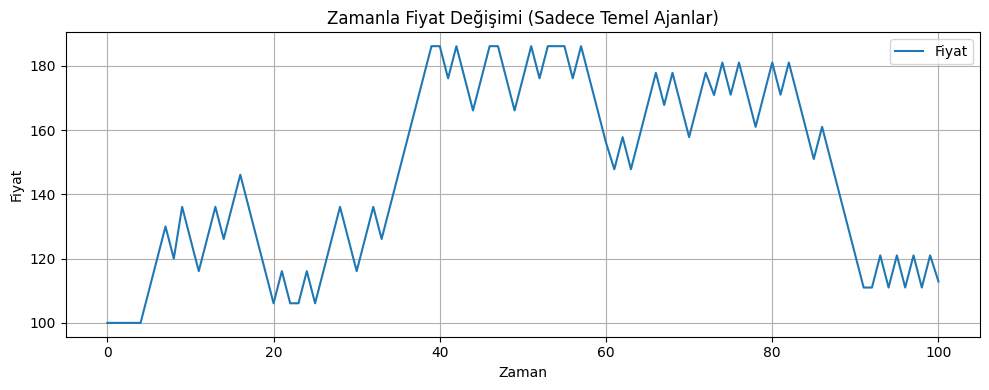

In [18]:
import matplotlib.pyplot as plt

# Sadece temel ajanlarla simülasyon
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# Fiyatları çiz
price_history = model.price_history
plt.figure(figsize=(10, 4))
plt.plot(price_history, label="Fiyat")
plt.title("Zamanla Fiyat Değişimi (Sadece Temel Ajanlar)")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Diğer Senaryoları Denemek İçin:

Sadece teknik ajanlar:

model = MarketModel(num_fundamental=0, num_technical=400, num_noise=0)



Sadece gürültü ajanları:

model = MarketModel(num_fundamental=0, num_technical=0, num_noise=400)



Üç ajan tipi bir arada (başlangıç oranı: eşit):

model = MarketModel(num_fundamental=400, num_technical=400, num_noise=400)




grafikte fundamental_history değerini de gösterelim:

Aşağıdaki kod:

model.fundamental_history listesini çeker.

matplotlib.pyplot.plot() fonksiyonunu kullanarak bu listeyi de aynı eksen üzerine çizdirir.

Temel değer serisi için ayrı bir label ("Temel Değer") ve farklı bir çizgi stili (örneğin linestyle='--') kullanarak iki seriyi ayırt etmeyi kolaylaştırır.

plt.legend() çağrısı ile etiketlerin grafikte görünmesini sağlar.

Grafik boyutunu figsize=(12, 6) yaparak daha okunabilir hale getirir.

Bu değişiklikleri yaptıktan sonra simülasyonu tekrar çalıştırdığınızda, fiyat serisinin yanında temel değer serisini de görebilirsiniz.
Bu, ajanların (bu durumda temel ajanların) fiyatı temel değere yaklaştırıp yaklaştırmadığını görsel olarak incelemenizi sağlar.

Step 1: Demand = 0, Supply = 0
Step 1: New Price = 100.0
Step 2: Demand = 0, Supply = 0
Step 2: New Price = 100.0
Step 3: Demand = 100, Supply = 0
Step 3: New Price = 110.0
Step 4: Demand = 0, Supply = 100
Step 4: New Price = 100.0
Step 5: Demand = 0, Supply = 0
Step 5: New Price = 100.0
Step 6: Demand = 254, Supply = 0
Step 6: New Price = 125.4
Step 7: Demand = 0, Supply = 200
Step 7: New Price = 105.4
Step 8: Demand = 100, Supply = 0
Step 8: New Price = 115.4
Step 9: Demand = 50, Supply = 127
Step 9: New Price = 107.7
Step 10: Demand = 0, Supply = 0
Step 10: New Price = 107.7
Step 11: Demand = 0, Supply = 0
Step 11: New Price = 107.7
Step 12: Demand = 100, Supply = 0
Step 12: New Price = 117.7
Step 13: Demand = 100, Supply = 0
Step 13: New Price = 127.7
Step 14: Demand = 100, Supply = 0
Step 14: New Price = 137.7
Step 15: Demand = 100, Supply = 0
Step 15: New Price = 147.7
Step 16: Demand = 0, Supply = 100
Step 16: New Price = 137.7
Step 17: Demand = 0, Supply = 100
Step 17: New Pric

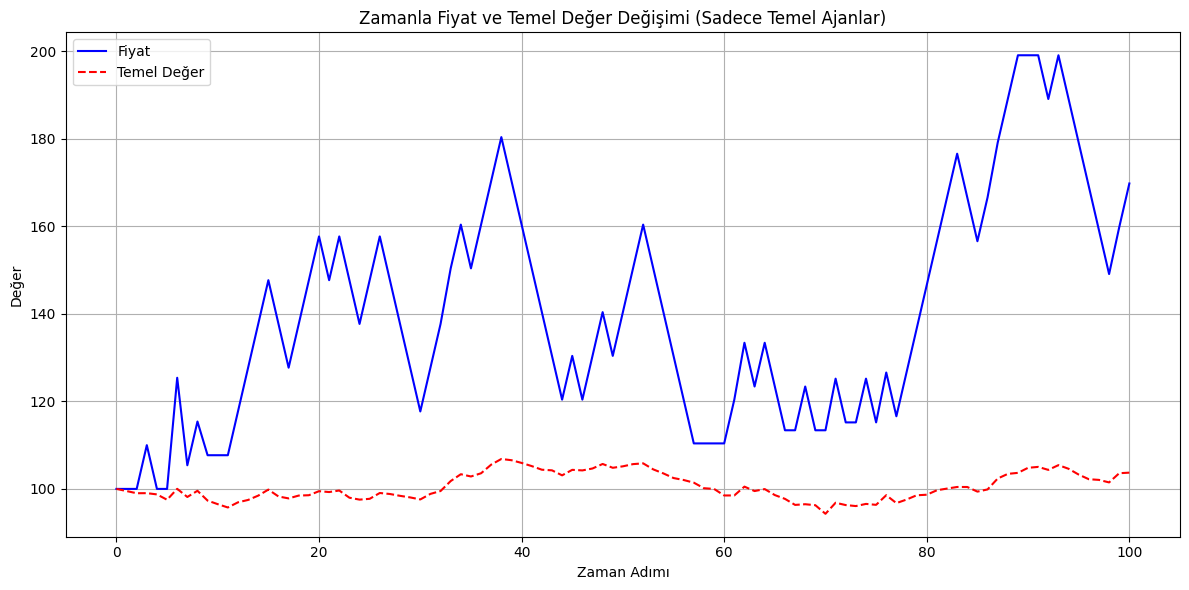

In [21]:
import matplotlib.pyplot as plt
# MarketModel sınıfınızın tanımlandığından emin olun (önceki hücreyi çalıştırarak)
# Agent ve strategy tanımlarının da yapıldığından emin olun

# Sadece temel ajanlarla simülasyon
# Daha önce düzeltilen MarketModel sınıfını kullanın
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# Fiyatları ve Temel Değeri çiz
price_history = model.price_history
fundamental_history = model.fundamental_history # Temel değer geçmişini al

plt.figure(figsize=(12, 6)) # Grafik boyutunu büyütelim
plt.plot(price_history, label="Fiyat", color='blue')
plt.plot(fundamental_history, label="Temel Değer", color='red', linestyle='--') # Temel değeri kesikli çizgiyle ekle

plt.title("Zamanla Fiyat ve Temel Değer Değişimi (Sadece Temel Ajanlar)")
plt.xlabel("Zaman Adımı")
plt.ylabel("Değer")
plt.grid(True)
plt.legend()
plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()

 **bu grafikte fiyat grafiği üzerinde temel ajan stratejilerinden hangisinin/hangilerinin aktif olduğunu gösterebilir miyiz. Al ve sat göstererek**

Bu da çok iyi bir analiz yöntemi! Hangi stratejilerin piyasa fiyatı üzerindeki etkisini veya belirli fiyat hareketlerine hangi stratejilerin neden olduğunu anlamak için ajanların uyguladığı stratejileri ve aldıkları aksiyonları görselleştirmek faydalı olacaktır.

Ancak, fiyat grafiğinin üzerine doğrudan "strateji 0 alım yaptı" gibi bilgileri tüm ajanlar için her adımda göstermek grafik karmaşıklığı açısından pratik olmayabilir. Toplam 400 temel ajan ve her adımda potansiyel olarak yüzlerce işlem oluyor.

Bunun yerine, daha yönetilebilir ve anlamlı görselleştirmeler düşünebiliriz:

1-Belirli Bir Stratejiyi Kullanan Ajanların Toplam Alım/Satım Miktarı: Her adımda, her bir strateji için (örneğin Temel Strateji 0, Temel Strateji 1 vb.) o stratejiyi kullanan ajanların toplam alım talebini ve toplam satım arzını ayrı ayrı toplayıp bu serileri çizebilirsiniz. Bu, hangi stratejinin belirli bir zamanda en aktif olduğunu gösterir.

2-Strateji Başına Ortalama Kâr/Zarar (Portföy Değeri): Zamanla her stratejiyi kullanan ajan grubunun ortalama portföy değerini (nakit + varlık değeri) çizerek hangi stratejinin daha başarılı olduğunu görebilirsiniz.

3-Belirli Bir Ajanın İşlemleri: İsterseniz simülasyondan rastgele veya ilginç davranan bir ajan seçip, o ajanın zaman içindeki alım/satım aksiyonlarını fiyat grafiği üzerinde işaretleyebilirsiniz (örneğin, alım yaptığı adımlara yeşil nokta, satım yaptığı adımlara kırmızı nokta koyarak).


İlk seçenek (Strateji Başına Toplam Talep/Arz) hem strateji aktivitesini gösterir hem de grafik üzerinde anlamlı bir yoğunluk sağlar. Bunu nasıl yapabileceğimize odaklanalım.

Suggested Changes
Bu görselleştirmeyi yapmak için aşağıdaki adımları izlememiz gerekiyor:

1-MarketModel'e Strateji Başına Talep/Arz Takibi Ekleme: Modelin her adımda, her temel strateji için ayrı ayrı toplam alım ve satım miktarını tutması gerekir.

2-DataCollector'a Bu Verileri Ekleme: Modelin topladığı bu yeni verileri DataCollector aracılığıyla kaydetmeliyiz.

3-Grafik Çizimi: Toplanan verileri kullanarak fiyat grafiği ile birlikte veya ayrı grafiklerde strateji bazlı talep/arz serilerini çizeceğiz.


##Adım 1 & 2: MarketModel ve DataCollector'u Güncelleme

MarketModel sınıfına, her strateji tipi ve ID'si için talep ve arzı tutacak dictionary'ler ekleyelim ve bunları DataCollector ile toplayalım.




In [7]:
# Make sure all necessary imports are here (mesa, random, DataCollector, SimultaneousActivation)
from mesa.datacollection import DataCollector
import random

class MarketModel(mesa.Model):
    def __init__(self,
                 num_fundamental=400,
                 num_technical=400,
                 num_noise=400,
                 initial_price=100,
                 initial_fundamental_value=100):
        super().__init__()


        # Initialize total demand and supply attributes for the model
        self.total_demand = 0
        self.total_supply = 0

        # Add dictionaries to track demand/supply per strategy
        self.fundamental_demand_by_strategy = {i: 0 for i in range(4)}
        self.fundamental_supply_by_strategy = {i: 0 for i in range(4)}
        # You can add similar dictionaries for technical and noise agents if needed

        self.price = initial_price
        self.prev_price = initial_price
        self.fundamental_value = initial_fundamental_value
        self.prev_fundamental_value = initial_fundamental_value
        self.price_history = [initial_price]
        self.fundamental_history = [initial_fundamental_value]
        self.step_count = 0

        # Ajanları oluştur
        for i in range(num_fundamental):
            strat_index = i % 4
            agent = FundamentalAgent(self, strat_index)
            self.agents.add(agent)

        for i in range(num_technical):
            strat_index = i % 4
            agent = TechnicalAgent(self, strat_index)
            self.agents.add(agent)

        for i in range(num_noise):
            strat_index = i % 4
            agent = NoiseAgent(self, strat_index)
            self.agents.add(agent)

        # Define data collectors for model variables
        model_reporters = {
            "Price": lambda m: m.price,
            "FundamentalValue": lambda m: m.fundamental_value,
            # Add reporters for strategy-specific demand/supply
            **{f"FundDemand_Strat{i}": lambda m, i=i: m.fundamental_demand_by_strategy[i] for i in range(4)},
            **{f"FundSupply_Strat{i}": lambda m, i=i: m.fundamental_supply_by_strategy[i] for i in range(4)},
            # Add reporters for other agent types if needed
        }

        self.datacollector = DataCollector(
            model_reporters=model_reporters
            # agent_reporters={} # You could add agent-specific reporters here later
        )

    def update_fundamental_value(self):
        shock = random.gauss(0, 1)
        self.prev_fundamental_value = self.fundamental_value
        self.fundamental_value += shock
        # fundamental_history is now redundant if using DataCollector,
        # but can keep it for direct access if preferred.

    def update_price(self, demand, supply):
        imbalance = demand - supply
        self.prev_price = self.price
        self.price += 0.1 * imbalance
        self.price = max(1, self.price)
        # price_history is now redundant if using DataCollector,
        # but can keep it for direct access if preferred.


    def step(self):
        """Zaman adımını ilerletir."""
        self.step_count += 1
        self.update_fundamental_value()

        # Reset total demand/supply for the model and for each strategy at the start of the step
        self.total_demand = 0
        self.total_supply = 0
        for i in range(4):
            self.fundamental_demand_by_strategy[i] = 0
            self.fundamental_supply_by_strategy[i] = 0
            # Reset for other agent types if you added them

        # Agent step method calls execute_action which updates model's attributes
        self.agents.do("step") # Agents update self.model.total_demand, self.model.total_supply
                             # and the strategy-specific dictionaries

        # Print demand and supply AFTER agents have stepped (Optional but good for debugging)
        # print(f"Step {self.step_count}: Demand = {self.total_demand}, Supply = {self.total_supply}")
        # print(f"Step {self.step_count}: Fund Demand by Strat: {self.fundamental_demand_by_strategy}")


        # Fiyat güncelle
        self.update_price(self.total_demand, self.total_supply) # Use model's attributes

        # Print price after update (Optional)
        # print(f"Step {self.step_count}: New Price = {self.price}")

        # Veri topla
        self.datacollector.collect(self)

    def run_model(self, steps=100):
        for _ in range(steps):
            self.step()

# Ensure agent classes are modified to update strategy-specific demand/supply
# Example modification for FundamentalAgent.execute_action below

Adım 1 (devamı): Ajan execute_action Metodlarını Güncelleme

Ajanların execute_action metodları, genel total_demand ve total_supply'ı güncellemenin yanı sıra kendi stratejilerine ait demand/supply dictionary'lerini de güncellemelidir.

In [8]:

class FundamentalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "fundamental", strategy_id)

    def step(self):
        # Ensure fundamental_strategies is accessible
        # from strategies import fundamental_strategies
        action = fundamental_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
            # Update strategy-specific demand
            if self.agent_type == "fundamental":
                 self.model.fundamental_demand_by_strategy[self.strategy_id] += 1
            # Add similar checks for other agent types if you track them
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
            # Update strategy-specific supply
            if self.agent_type == "fundamental":
                self.model.fundamental_supply_by_strategy[self.strategy_id] += 1
        self.last_action = action

# You would need to add similar updates in TechnicalAgent and NoiseAgent
# execute_action methods if you plan to track their strategy-specific activity.
# For example, in TechnicalAgent:
# if self.agent_type == "technical":
#    self.model.technical_demand_by_strategy[self.strategy_id] += 1 # Assuming you added this dict to model

Adım 3: Grafik Çizimi

Simülasyonu çalıştırdıktan sonra DataCollector'dan verileri alıp matplotlib ile çizebilirsiniz. Temel strateji bazlı talep ve arzı, fiyat grafiğinin altında ayrı subplots olarak göstermek genellikle daha anlaşılır olur.

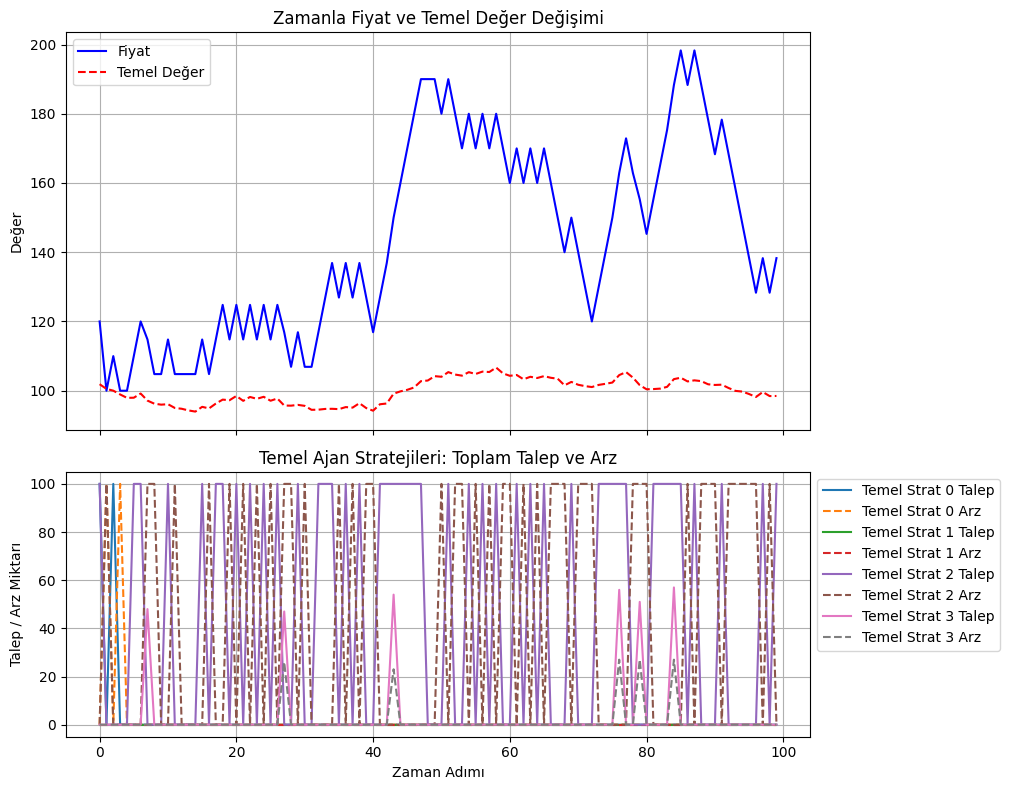

In [9]:
import matplotlib.pyplot as plt


# Assuming MarketModel, Agent classes, and strategies are defined and updated.

# Run the simulation
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0) # Example: only fundamental agents
model.run_model(steps=100)

# Get the data from the DataCollector
results_df = model.datacollector.get_model_vars_dataframe()

# Plotting
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 2]}) # Two plots, price on top

# Plot Price and Fundamental Value on the top subplot
axes[0].plot(results_df.index, results_df["Price"], label="Fiyat", color='blue')
axes[0].plot(results_df.index, results_df["FundamentalValue"], label="Temel Değer", color='red', linestyle='--')
axes[0].set_ylabel("Değer")
axes[0].set_title("Zamanla Fiyat ve Temel Değer Değişimi")
axes[0].grid(True)
axes[0].legend()

# Plot Strategy-Specific Demand/Supply on the bottom subplot
# Only plot for Fundamental agents as per your request
axes[1].set_ylabel("Talep / Arz Miktarı")
axes[1].set_xlabel("Zaman Adımı")
axes[1].set_title("Temel Ajan Stratejileri: Toplam Talep ve Arz")
axes[1].grid(True)

# Plot demand and supply for each Fundamental strategy
for i in range(4):
    axes[1].plot(results_df.index, results_df[f"FundDemand_Strat{i}"], label=f"Temel Strat {i} Talep", linestyle='-')
    axes[1].plot(results_df.index, results_df[f"FundSupply_Strat{i}"], label=f"Temel Strat {i} Arz", linestyle='--')

axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1)) # Place legend outside the plot

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

Bu kod, fiyat ve temel değeri üst grafikte, her temel stratejinin toplam alım (Talep) ve satım (Arz) miktarını ise alt grafikte gösterecektir. Bu sayede, belirli bir stratejinin piyasa hareketlerine ne zaman ve ne kadar yoğunlukta katkı sağladığını görebilirsiniz.

Eğer teknik veya gürültü ajanlarının stratejilerini de göstermek isterseniz, MarketModel'e bunlar için de dictionary'ler eklemeli, ajanların execute_action metodlarını güncellemelisiniz ve çizim koduna ilgili serileri eklemelisiniz.

-----------
**Strateji Başına Ortalama Kâr/Zarar (Portföy Değeri): Zamanla her stratejiyi kullanan ajan grubunun ortalama portföy değerini (nakit + varlık değeri) çizerek hangi stratejinin daha başarılı olduğunu göreceğimiz kodu yazabiliriz**
